# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


Dataset yang digunakan adalah Telco Customer Churn IBM Dataset, yang berisi informasi pelanggan perusahaan telekomunikasi, mencakup data demografis, layanan yang digunakan, serta informasi akun pelanggan.

Dataset ini digunakan untuk menganalisis perilaku pelanggan dan memprediksi kemungkinan customer churn, yaitu kondisi ketika pelanggan berhenti menggunakan layanan.

Target variabel pada dataset ini adalah Churn, yang bersifat klasifikasi biner (Yes/No).

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# 3.1. LOAD DATASET
url = "https://docs.google.com/spreadsheets/d/15D7O9LWyW_KpULzVR0aQJC3vY1DovTf4/export?format=xlsx"

df = pd.read_excel(url)

# 3.2. Preview
df.head()

# 3.3. Basic info
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges,numAdminTickets,numTechTickets
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.515689,0.419566
std,0.368612,24.559481,30.090047,1.275299,1.250117
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,0.000000,0.000000
50%,0.000000,29.000000,70.350000,0.000000,0.000000
75%,0.000000,55.000000,89.850000,0.000000,0.000000
max,1.000000,72.000000,118.750000,5.000000,9.000000


Dataset didominasi fitur kategorikal sehingga memerlukan encoding. Target Churn merupakan klasifikasi biner dan perlu dikonversi ke numerik. Kolom TotalCharges terindikasi memiliki tipe data tidak sesuai sehingga perlu dibersihkan. Fitur numerik memiliki skala berbeda sehingga membutuhkan scaling. Selain itu, fitur seperti jumlah tiket dan tenure berpotensi kuat dalam memprediksi churn, sehingga dipertahankan dan dapat dikembangkan melalui feature engineering.

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [3]:
# DATA CLEANING AWAL

# Fix TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop kolom ID (tidak relevan untuk analisis)
df = df.drop('customerID', axis=1)

# Fix tipe data (binary -> categorical)
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')

cat_cols = df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Validasi missing yang sebelumnya tersembunyi
print("Missing TotalCharges setelah cleaning:", df['TotalCharges'].isnull().sum())

Missing TotalCharges setelah cleaning: 11


Pembersihan dilakukan pada kolom TotalCharges yang memiliki nilai kosong tersembunyi dan tipe data tidak sesuai, menghasilkan 11 missing values yang akan ditangani pada tahap preprocessing. Kolom customerID dihapus karena tidak relevan, dan SeniorCitizen dikonversi menjadi kategorikal untuk menghindari misinterpretasi numerik. Selain itu, fitur dipisahkan menjadi kategorikal dan numerik untuk mempermudah proses preprocessing selanjutnya.

In [4]:
# 4.1 Struktur Data
df.shape
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'numAdminTickets', 'numTechTickets',
       'Churn'],
      dtype='object')

Dataset memiliki 7043 data dan 22 fitur yang mencakup aspek demografis, layanan, finansial, dan perilaku pelanggan, sehingga cukup representatif untuk analisis churn. Seluruh fitur dipertahankan untuk eksplorasi lebih lanjut sebelum dilakukan seleksi fitur.
Variasi jenis fitur ini memungkinkan model menangkap pola churn dari berbagai perspektif pelanggan.

In [5]:
# 4.2. Cek Missing Value
print("\nMissing Values:\n", df.isnull().sum())

# 4.1. Cek Duplicate
print("\nDuplicate:\n",df.duplicated().sum())



Missing Values:
 gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
numAdminTickets      0
numTechTickets       0
Churn                0
dtype: int64

Duplicate:
 17


Terdapat 11 missing values pada TotalCharges yang akan dihapus karena jumlahnya sangat kecil. Selain itu, ditemukan 17 data duplikat yang juga dihapus untuk menghindari bias pada model.
Menghapus missing dan duplikat dilakukan untuk memastikan model belajar dari data yang bersih dan tidak bias.

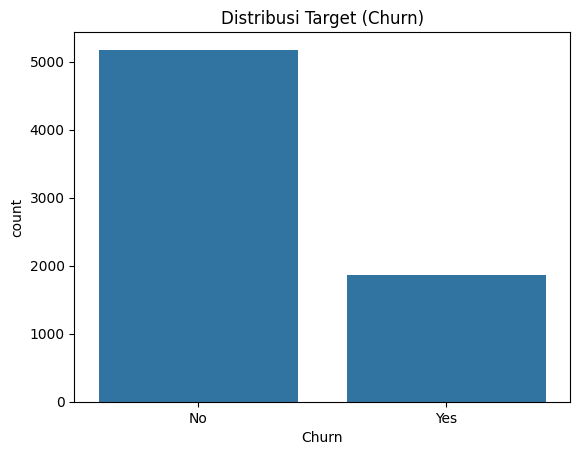

,count,ratio
Churn,,
No,5174,0.73463
Yes,1869,0.26537


In [6]:
# 3. Distribusi Target
sns.countplot(x='Churn', data=df)
plt.title("Distribusi Target (Churn)")
plt.show()

df['Churn'].value_counts(normalize=True)

# 4. Distribusi target (count + percentage)
target_dist = df['Churn'].value_counts()
target_ratio = df['Churn'].value_counts(normalize=True)

pd.DataFrame({
    'count': target_dist,
    'ratio': target_ratio
})

In [7]:
# Insight: Imbalance target
churn_ratio = df['Churn'].value_counts(normalize=True)

print("Churn Ratio:\n", churn_ratio)

if churn_ratio.min() < 0.3:
    print("\n⚠️ Dataset imbalanced → perlu perhatian saat modeling")

Churn Ratio:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

⚠️ Dataset imbalanced → perlu perhatian saat modeling


Distribusi target menunjukkan ketidakseimbangan kelas, dengan proporsi 73.46% (No) dan 26.54% (Yes).

Kondisi ini dikonfirmasi melalui perhitungan rasio churn, di mana kelas minoritas berada di bawah threshold 30%, sehingga dataset dikategorikan sebagai imbalanced.

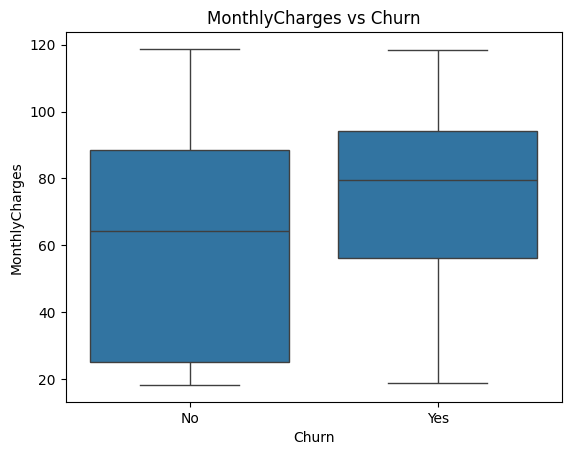

In [8]:
# 4.6 Analisis Fitur
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("MonthlyCharges vs Churn")
plt.show()

Pelanggan dengan biaya bulanan lebih tinggi cenderung lebih sering churn, sehingga MonthlyCharges menjadi fitur penting dalam prediksi churn.
Hal ini menunjukkan bahwa harga menjadi faktor sensitif dalam retensi pelanggan, sehingga model perlu mampu menangkap interaksi antara biaya dan durasi langganan (tenure).

In [9]:
# 5. Categorical vs Numerical
print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')
Numerical: Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'numAdminTickets',
       'numTechTickets'],
      dtype='object')


Fitur dipisahkan menjadi kategorikal dan numerik untuk mempermudah proses encoding dan scaling dalam tahap preprocessing.

In [10]:
# 6. Crosstab categorical vs churn
for col in cat_cols:
    if col != 'Churn':  # optional biar ga compare ke diri sendiri
        print(f"\n=== {col} vs Churn ===")
        print(pd.crosstab(df[col], df['Churn'], normalize='index'))


=== gender vs Churn ===
Churn         No       Yes
gender                    
Female  0.730791  0.269209
Male    0.738397  0.261603

=== SeniorCitizen vs Churn ===
Churn                No       Yes
SeniorCitizen                    
0              0.763938  0.236062
1              0.583187  0.416813

=== Partner vs Churn ===
Churn          No       Yes
Partner                    
No       0.670420  0.329580
Yes      0.803351  0.196649

=== Dependents vs Churn ===
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.845498  0.154502

=== PhoneService vs Churn ===
Churn               No       Yes
PhoneService                    
No            0.750733  0.249267
Yes           0.732904  0.267096

=== MultipleLines vs Churn ===
Churn                   No       Yes
MultipleLines                       
No                0.749558  0.250442
No phone service  0.750733  0.249267
Yes               0.713901  0.286099

=== InternetService vs Chur

Faktor utama churn berasal dari jenis kontrak, layanan internet, dan ketersediaan layanan tambahan seperti tech support. Pelanggan dengan kontrak fleksibel, menggunakan fiber optic, serta tanpa layanan support memiliki kecenderungan churn lebih tinggi. Sebaliknya, faktor demografis seperti gender tidak menunjukkan pengaruh signifikan.

In [11]:
# 7. Statistik Numerical per Churn
df.groupby('Churn')[num_cols].describe()

tenure                                                     \
        count       mean        std  min   25%   50%   75%   max   
Churn                                                              
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0   
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0   

      MonthlyCharges             ... numAdminTickets      numTechTickets  \
               count       mean  ...             75%  max          count   
Churn                            ...                                       
No            5174.0  61.265124  ...             0.0  5.0         5174.0   
Yes           1869.0  74.441332  ...             0.0  5.0         1869.0   

                                                    
           mean       std  min  25%  50%  75%  max  
Churn                                               
No     0.151140  0.711373  0.0  0.0  0.0  0.0  7.0  
Yes    1.162654  1.933387  0.0  0.0  0.0  2.0  9.0  

[2 rows x 40 columns]

Pelanggan yang churn cenderung memiliki tenure lebih pendek, biaya bulanan lebih tinggi, dan jumlah komplain lebih banyak. Hal ini menunjukkan bahwa churn banyak terjadi pada pelanggan baru yang tidak puas dengan layanan.

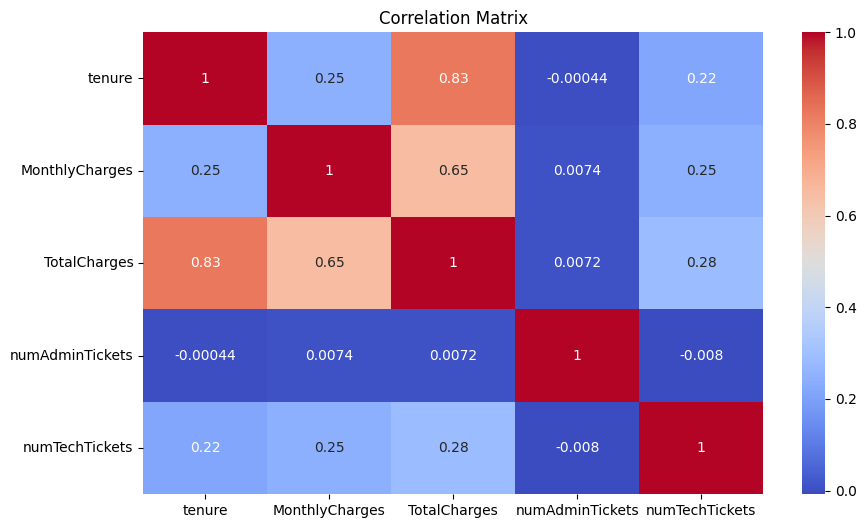

,tenure,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets
tenure,1.000000,0.247900,0.825880,-0.000440,0.215158
MonthlyCharges,0.247900,1.000000,0.651065,0.007386,0.245081
TotalCharges,0.825880,0.651065,1.000000,0.007200,0.283839
numAdminTickets,-0.000440,0.007386,0.007200,1.000000,-0.008004
numTechTickets,0.215158,0.245081,0.283839,-0.008004,1.000000


In [12]:
# 8. Korelasi (Numerical)
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Korelasi (versi numerik)
df[num_cols].corr()

In [13]:
# Fokus multicollinearity
corr_focus = df[['tenure','MonthlyCharges','TotalCharges']].corr()
print("\nCorrelation Focus:\n", corr_focus)


Correlation Focus:
                  tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000


Analisis korelasi terfokus menunjukkan bahwa TotalCharges sangat berkorelasi dengan tenure dan MonthlyCharges, sehingga berpotensi menyebabkan multikolinearitas dan perlu ditangani melalui feature selection atau feature engineering.

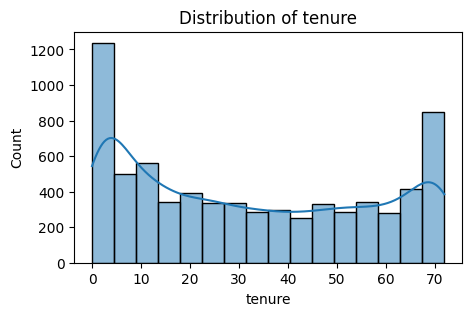

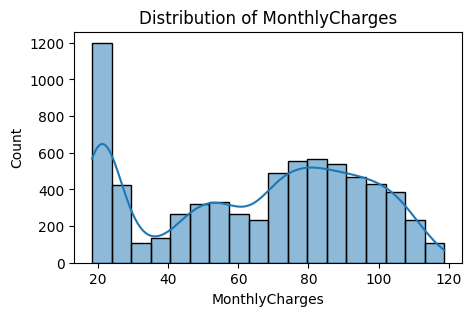

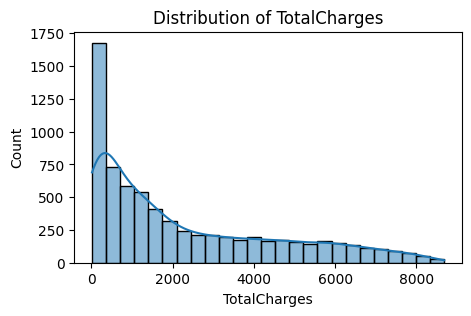

Skewness:
 tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64


In [14]:
# Skew data
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
print("Skewness:\n", df[['tenure','MonthlyCharges','TotalCharges']].skew())

TotalCharges menunjukkan distribusi skewed sehingga memerlukan transformasi atau feature engineering, sedangkan MonthlyCharges relatif stabil dan cukup dilakukan scaling. Selain itu, tenure menunjukkan pola distribusi yang mengindikasikan adanya perbedaan antara pelanggan baru dan pelanggan lama, sehingga menjadi fitur penting dalam memahami perilaku churn.

In [15]:
# 10. Churn rate per category (ranking)
def churn_rate_per_col(df, col):
    return df.groupby(col)['Churn'].value_counts(normalize=True).unstack()

churn_rate_per_col(df, 'Contract')

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


Kontrak jangka pendek memiliki churn rate jauh lebih tinggi, sehingga Contract menjadi fitur kunci dalam prediksi churn.

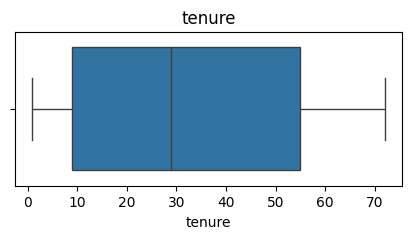

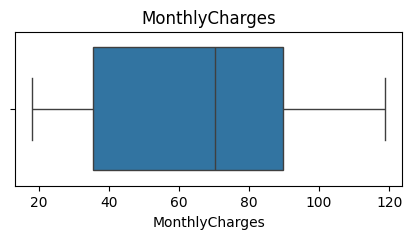

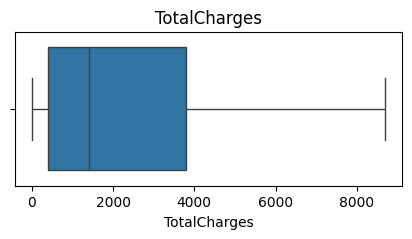

In [16]:
# 11. Pengecekan Outlier
# persiapan
def prepare_for_outlier(df):
    df = df.copy()

    # Drop NaN hasil coercion (biar bersih & no warning)
    df = df.dropna(subset=['TotalCharges'])

    return df
df_clean = prepare_for_outlier(df)

# Boxplot
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

In [17]:
# Summary pengecekan outlier
def outlier_summary(df):
    cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

    summary = []

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        summary.append({
            'feature': col,
            'Q1': round(Q1,2),
            'Q3': round(Q3,2),
            'IQR': round(IQR,2),
            'lower_bound': round(lower,2),
            'upper_bound': round(upper,2),
            'num_outliers': len(outliers),
            'percentage_outliers': round(len(outliers)/len(df), 4)
        })

    return pd.DataFrame(summary).sort_values(by='percentage_outliers', ascending=False)

outlier_df = outlier_summary(df_clean)
outlier_df

,feature,Q1,Q3,IQR,lower_bound,upper_bound,num_outliers,percentage_outliers
0,tenure,9.00,55.00,46.00,-60.00,124.00,0,0.0
1,MonthlyCharges,35.59,89.86,54.28,-45.82,171.27,0,0.0
2,TotalCharges,401.45,3794.74,3393.29,-4688.48,8884.67,0,0.0


Tidak ditemukan outlier signifikan, sehingga tidak diperlukan penanganan khusus pada fitur numerik.
Hal ini menunjukkan bahwa variasi nilai pada dataset masih dalam batas normal dan representatif terhadap kondisi pelanggan.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# DATA CLEANING

# Copy data
df = df.copy()

# Drop ID (tidak relevan)
df = df.drop(columns=['customerID'], errors='ignore')

# Fix TotalCharges dan tipe
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['SeniorCitizen'] = df['SeniorCitizen'].astype('object')
replace_map = {
        'No internet service': 'No',
        'No phone service': 'No'}
obj_cols = df.select_dtypes(include='object').columns

for col in obj_cols:
        df[col] = df[col].apply(lambda x: replace_map.get(x, x))

# Remove duplicate
df = df.drop_duplicates()

In [19]:
# HANDLE MISSING

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [20]:
# FEATURE ENGINEERING

# Binning tenure
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 36, 72],
    labels=['short', 'medium', 'long']
)

# Feature baru
df['avg_charge'] = df['TotalCharges'] / (df['tenure'] + 1)

In [21]:
# FEATURE SELECTION

# Drop redundant (multicollinearity tinggi)
df = df.drop(columns=['TotalCharges'])


In [22]:
# ENCODING

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode categorical
cat_cols = df.select_dtypes(include=['object', 'category']).columns

df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

In [23]:
# FINAL

# Bool → int (best practice)
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)

# SOURCE OF TRUTH
df.columns = df.columns.str.replace(" ", "_", regex=False)
df.columns = df.columns.str.replace("(", "", regex=False)
df.columns = df.columns.str.replace(")", "", regex=False)

# Final Validation
print("Shape:", df.shape)
print("Missing:", df.isnull().sum().sum())

df.head()

Shape: (7026, 28)
Missing: 0


,SeniorCitizen,tenure,MonthlyCharges,numAdminTickets,numTechTickets,Churn,avg_charge,gender_Male,Partner_Yes,Dependents_Yes,...,StreamingTV_Yes,StreamingMovies_Yes,Contract_One_year,Contract_Two_year,PaperlessBilling_Yes,PaymentMethod_Credit_card_automatic,PaymentMethod_Electronic_check,PaymentMethod_Mailed_check,tenure_group_medium,tenure_group_long
0,0,1,29.85,0,0,0,14.925000,0,1,0,...,0,0,0,0,1,0,1,0,0,0
1,0,34,56.95,0,0,0,53.985714,1,0,0,...,0,0,1,0,0,0,0,1,1,0
2,0,2,53.85,0,0,1,36.050000,1,0,0,...,0,0,0,0,1,0,0,1,0,0
3,0,45,42.30,0,3,0,40.016304,1,0,0,...,0,0,1,0,0,0,0,0,0,1
4,0,2,70.70,0,0,1,50.550000,0,0,0,...,0,0,0,0,1,0,1,0,0,0


Tahap preprocessing dilakukan untuk memastikan kualitas data dan kesiapan model, meliputi pembersihan data, penanganan missing value, feature engineering, serta encoding. Selain itu, dilakukan penghapusan fitur redundan akibat multikolinearitas dan penambahan fitur baru untuk meningkatkan representasi pola churn.
Pipeline preprocessing ini dirancang modular sehingga dapat digunakan kembali pada data baru dalam tahap deployment.